In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.risk.gjr_garch import (
    load_portfolio_returns,
    run_gjr_garch,
)

In [2]:
portfolio_file = (
    PROJECT_ROOT
    / "data"
    / "portfolio"
    / "portfolio_daily.csv"
)

returns = load_portfolio_returns(
    portfolio_file
)

returns.head()

Date
2020-01-03   -0.009045
2020-01-06    0.009246
2020-01-07   -0.000913
2020-01-08    0.009735
2020-01-09    0.009290
Name: Portfolio Return, dtype: float64

In [3]:
results = run_gjr_garch(
    returns
)


In [4]:
parameters = results["parameters"]

parameters

{'omega': 0.06695367445585125,
 'alpha': 0.008333860862138463,
 'gamma': 0.1318351596576148,
 'beta': 0.8949066816054133,
 'persistence': 0.9691581222963592}

In [5]:
forecast_volatility = (
    results["forecast_volatility"]
)

print(
    f"1-Day Forecast Volatility: "
    f"{forecast_volatility:.6%}"
)

1-Day Forecast Volatility: 1.375482%


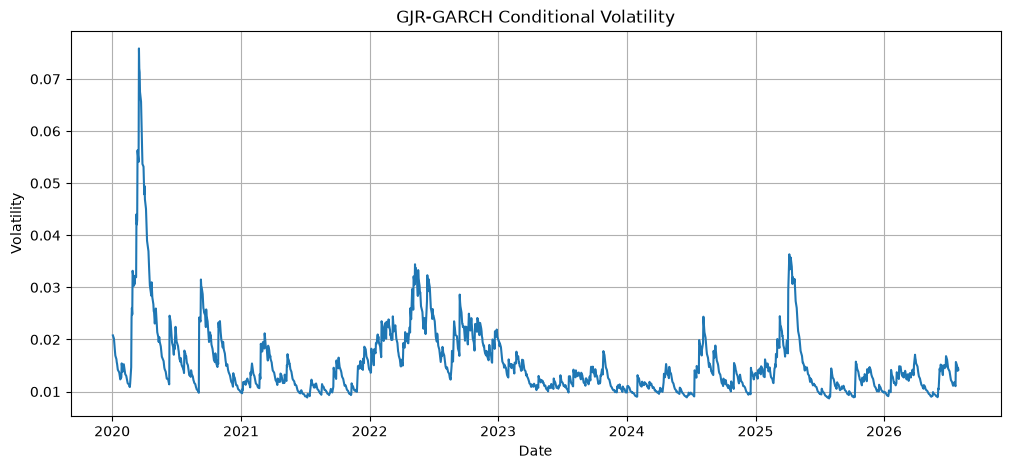

In [6]:
volatility = (
    results["conditional_volatility"]
)

plt.figure(figsize=(12, 5))

plt.plot(
    volatility.index,
    volatility.values,
)

plt.title(
    "GJR-GARCH Conditional Volatility"
)

plt.xlabel("Date")
plt.ylabel("Volatility")

plt.grid(True)
plt.show()

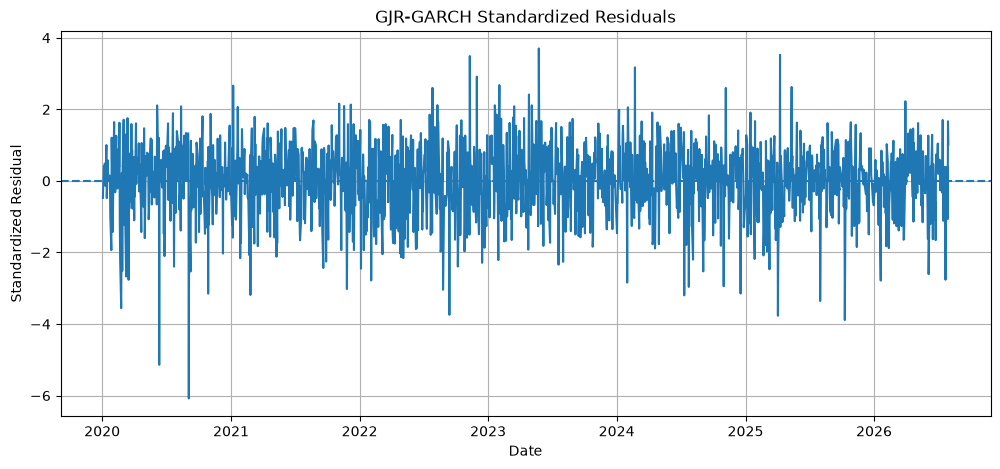

In [7]:
residuals = (
    results["standardized_residuals"]
)

plt.figure(figsize=(12, 5))

plt.plot(
    residuals.index,
    residuals.values,
)

plt.axhline(
    0,
    linestyle="--",
)

plt.title(
    "GJR-GARCH Standardized Residuals"
)

plt.xlabel("Date")
plt.ylabel("Standardized Residual")

plt.grid(True)
plt.show()

In [8]:
gamma = parameters["gamma"]

print(
    f"Leverage Effect Parameter (Gamma): "
    f"{gamma:.6f}"
)

Leverage Effect Parameter (Gamma): 0.131835


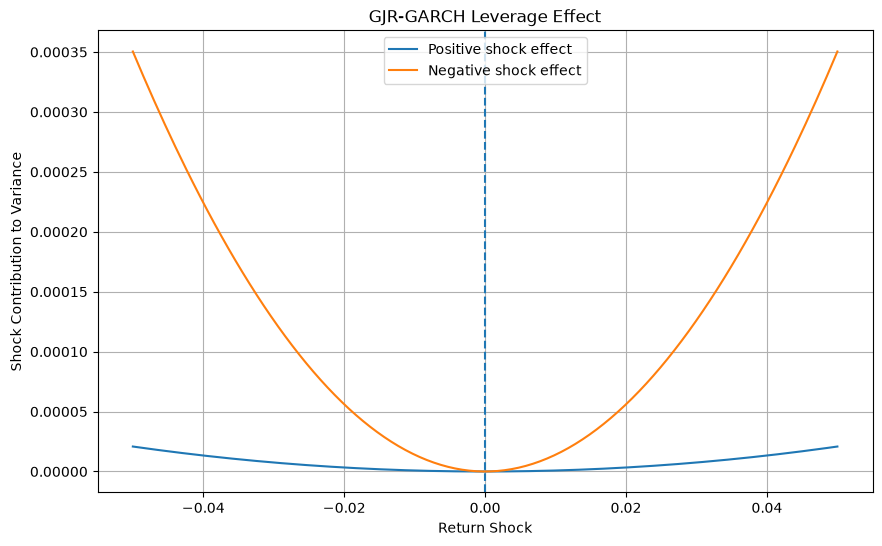

In [9]:
import numpy as np

shock = np.linspace(
    -0.05,
    0.05,
    200,
)

alpha = parameters["alpha"]

positive_effect = (
    alpha * shock**2
)

negative_effect = (
    (alpha + gamma) * shock**2
)

plt.figure(figsize=(10, 6))

plt.plot(
    shock,
    positive_effect,
    label="Positive shock effect",
)

plt.plot(
    shock,
    negative_effect,
    label="Negative shock effect",
)

plt.axvline(
    0,
    linestyle="--",
)

plt.title(
    "GJR-GARCH Leverage Effect"
)

plt.xlabel("Return Shock")
plt.ylabel("Shock Contribution to Variance")

plt.legend()
plt.grid(True)
plt.show()

In [10]:
garch_file = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "garch_volatility.csv"
)

gjr_file = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "gjr_garch_volatility.csv"
)

garch = pd.read_csv(
    garch_file,
    parse_dates=["Date"],
)

gjr = pd.read_csv(
    gjr_file,
    parse_dates=["Date"],
)

In [13]:
# Display actual columns first
print("GARCH columns:")
print(garch.columns.tolist())

print("\nGJR-GARCH columns:")
print(gjr.columns.tolist())

GARCH columns:
['Date', 'Portfolio Return', 'Conditional Volatility', 'Standardized Residual']

GJR-GARCH columns:
['Date', 'GJR-GARCH Conditional Volatility', 'Standardized Residual']


In [15]:
# ---------------------------------------------------------
# Identify volatility columns
# ---------------------------------------------------------

garch_vol_col = None

for col in garch.columns:
    if "volatility" in col.lower():
        if col.lower() != "forecast volatility":
            garch_vol_col = col
            break

gjr_vol_col = None

for col in gjr.columns:
    if "volatility" in col.lower():
        if col.lower() != "forecast volatility":
            gjr_vol_col = col
            break

if garch_vol_col is None:
    raise ValueError(
        f"Could not find GARCH volatility column. "
        f"Available columns: {garch.columns.tolist()}"
    )

if gjr_vol_col is None:
    raise ValueError(
        f"Could not find GJR-GARCH volatility column. "
        f"Available columns: {gjr.columns.tolist()}"
    )

print("GARCH volatility column:")
print(garch_vol_col)

print("\nGJR-GARCH volatility column:")
print(gjr_vol_col)

GARCH volatility column:
Conditional Volatility

GJR-GARCH volatility column:
GJR-GARCH Conditional Volatility


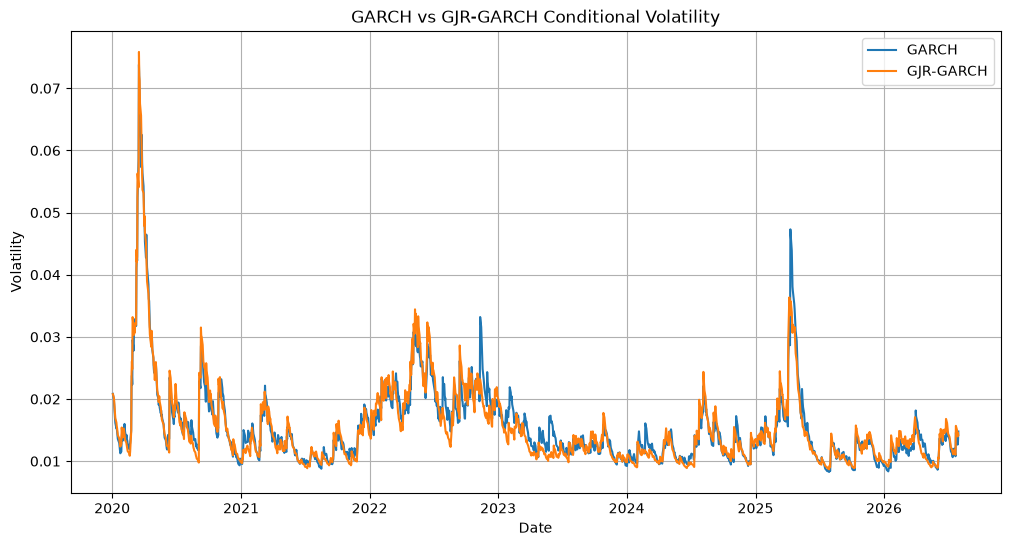

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    garch["Date"],
    garch[garch_vol_col],
    label="GARCH",
)

plt.plot(
    gjr["Date"],
    gjr[gjr_vol_col],
    label="GJR-GARCH",
)

plt.title(
    "GARCH vs GJR-GARCH Conditional Volatility"
)

plt.xlabel("Date")
plt.ylabel("Volatility")

plt.legend()
plt.grid(True)

plt.show()

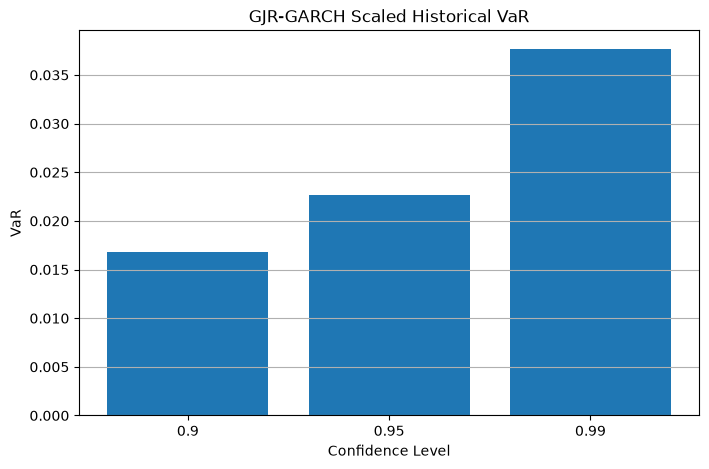

In [17]:
var_table = results["var_table"]

plt.figure(figsize=(8, 5))

plt.bar(
    var_table["Confidence"].astype(str),
    var_table["VaR"],
)

plt.title(
    "GJR-GARCH Scaled Historical VaR"
)

plt.xlabel("Confidence Level")
plt.ylabel("VaR")

plt.grid(
    axis="y"
)

plt.show()